In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [33]:
df=pd.read_excel("Validation_Data.xlsx")
df

,branch,ncust,customer,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,Y,pd_pred,Default_Pred,Grade,Score
0,3,3017,10012,28,2,7,2,44,17.7,2.99,4.80,0,0.517544,0.626573,1,12,472.189844
1,3,3017,10017,64,5,34,17,116,14.7,5.05,12.00,0,-6.042531,0.002370,0,2,661.473571
2,3,3017,10030,40,1,20,12,61,4.8,1.04,1.89,0,-4.971149,0.006887,0,4,630.560048
3,3,3017,10039,30,1,11,3,27,34.5,1.75,7.56,0,0.737179,0.676379,1,12,465.852521
4,3,3017,10069,25,1,2,2,30,22.4,0.76,5.96,1,1.182130,0.765330,1,12,453.013952
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,91,3779,453471,34,3,8,4,83,11.0,1.85,7.28,0,-1.144578,0.241481,0,10,520.148531
1496,91,3779,453578,37,2,10,8,43,3.6,0.81,0.74,0,-2.985767,0.048073,0,8,573.274035
1497,91,3779,453686,25,5,0,3,16,3.2,0.29,0.22,0,-0.746154,0.321660,0,11,508.652451
1498,91,3779,453698,34,1,10,8,41,14.5,1.19,4.75,0,-1.492925,0.183483,0,10,530.199710


# Goods vs Bads

In [36]:
bucket_edges = [0,60] + list(np.arange(72,864,12))
bucket_edges

[0,
 60,
 72,
 84,
 96,
 108,
 120,
 132,
 144,
 156,
 168,
 180,
 192,
 204,
 216,
 228,
 240,
 252,
 264,
 276,
 288,
 300,
 312,
 324,
 336,
 348,
 360,
 372,
 384,
 396,
 408,
 420,
 432,
 444,
 456,
 468,
 480,
 492,
 504,
 516,
 528,
 540,
 552,
 564,
 576,
 588,
 600,
 612,
 624,
 636,
 648,
 660,
 672,
 684,
 696,
 708,
 720,
 732,
 744,
 756,
 768,
 780,
 792,
 804,
 816,
 828,
 840,
 852]

In [38]:
df['Bucket'] = pd.cut(df['Score'], bins=bucket_edges)
df

,branch,ncust,customer,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,Y,pd_pred,Default_Pred,Grade,Score,Bucket
0,3,3017,10012,28,2,7,2,44,17.7,2.99,4.80,0,0.517544,0.626573,1,12,472.189844,"(468, 480]"
1,3,3017,10017,64,5,34,17,116,14.7,5.05,12.00,0,-6.042531,0.002370,0,2,661.473571,"(660, 672]"
2,3,3017,10030,40,1,20,12,61,4.8,1.04,1.89,0,-4.971149,0.006887,0,4,630.560048,"(624, 636]"
3,3,3017,10039,30,1,11,3,27,34.5,1.75,7.56,0,0.737179,0.676379,1,12,465.852521,"(456, 468]"
4,3,3017,10069,25,1,2,2,30,22.4,0.76,5.96,1,1.182130,0.765330,1,12,453.013952,"(444, 456]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,91,3779,453471,34,3,8,4,83,11.0,1.85,7.28,0,-1.144578,0.241481,0,10,520.148531,"(516, 528]"
1496,91,3779,453578,37,2,10,8,43,3.6,0.81,0.74,0,-2.985767,0.048073,0,8,573.274035,"(564, 576]"
1497,91,3779,453686,25,5,0,3,16,3.2,0.29,0.22,0,-0.746154,0.321660,0,11,508.652451,"(504, 516]"
1498,91,3779,453698,34,1,10,8,41,14.5,1.19,4.75,0,-1.492925,0.183483,0,10,530.199710,"(528, 540]"


# Default and Non Defaults in each Bucket

In [41]:
bucket_stats = df.groupby('Bucket').agg(
    default= ('default', lambda x:(x==1).sum()),
    non_default = ('default', lambda x: (x==0).sum())
)

In [43]:
bucket_stats= bucket_stats.reset_index()
bucket_stats

,Bucket,default,non_default
0,"(0, 60]",0,0
1,"(60, 72]",1,0
2,"(72, 84]",0,0
3,"(84, 96]",0,0
4,"(96, 108]",0,0
...,...,...,...
62,"(792, 804]",0,0
63,"(804, 816]",0,1
64,"(816, 828]",0,0
65,"(828, 840]",0,0


# Cumulative No of Goods and Cumulative No of Bads in each bucket

In [46]:
bucket_stats['cum_goods']=bucket_stats['non_default'].cumsum()
bucket_stats['cum_bads']= bucket_stats['default'].cumsum()
bucket_stats

,Bucket,default,non_default,cum_goods,cum_bads
0,"(0, 60]",0,0,0,0
1,"(60, 72]",1,0,0,1
2,"(72, 84]",0,0,0,1
3,"(84, 96]",0,0,0,1
4,"(96, 108]",0,0,0,1
...,...,...,...,...,...
62,"(792, 804]",0,0,950,548
63,"(804, 816]",0,1,951,548
64,"(816, 828]",0,0,951,548
65,"(828, 840]",0,0,951,548


# Cum % goods and cum % bads

In [49]:
total_goods = bucket_stats['non_default'].sum()
total_bads = bucket_stats['default'].sum()

In [51]:
total_goods, total_bads

(952, 548)

In [55]:
bucket_stats['cum_%_goods']=bucket_stats['cum_goods']/total_goods
bucket_stats['cum_%_bads']=bucket_stats['cum_bads']/total_bads
bucket_stats

,Bucket,default,non_default,cum_goods,cum_bads,cum_%_goods,cum_%_bads
0,"(0, 60]",0,0,0,0,0.000000,0.000000
1,"(60, 72]",1,0,0,1,0.000000,0.001825
2,"(72, 84]",0,0,0,1,0.000000,0.001825
3,"(84, 96]",0,0,0,1,0.000000,0.001825
4,"(96, 108]",0,0,0,1,0.000000,0.001825
...,...,...,...,...,...,...,...
62,"(792, 804]",0,0,950,548,0.997899,1.000000
63,"(804, 816]",0,1,951,548,0.998950,1.000000
64,"(816, 828]",0,0,951,548,0.998950,1.000000
65,"(828, 840]",0,0,951,548,0.998950,1.000000


In [57]:
total_popln = total_goods + total_bads
total_popln

1500

In [59]:
bucket_stats['cum_%_total']= (bucket_stats['cum_goods'] + bucket_stats['cum_bads'])/total_popln
bucket_stats

,Bucket,default,non_default,cum_goods,cum_bads,cum_%_goods,cum_%_bads,cum_%_total
0,"(0, 60]",0,0,0,0,0.000000,0.000000,0.000000
1,"(60, 72]",1,0,0,1,0.000000,0.001825,0.000667
2,"(72, 84]",0,0,0,1,0.000000,0.001825,0.000667
3,"(84, 96]",0,0,0,1,0.000000,0.001825,0.000667
4,"(96, 108]",0,0,0,1,0.000000,0.001825,0.000667
...,...,...,...,...,...,...,...,...
62,"(792, 804]",0,0,950,548,0.997899,1.000000,0.998667
63,"(804, 816]",0,1,951,548,0.998950,1.000000,0.999333
64,"(816, 828]",0,0,951,548,0.998950,1.000000,0.999333
65,"(828, 840]",0,0,951,548,0.998950,1.000000,0.999333


# Marginal % Bads and Marginal % Goods

In [62]:
bucket_stats['marginal_%_Goods']=bucket_stats['non_default']/total_goods
bucket_stats['marginal_%_Bads']=bucket_stats['default']/total_bads
bucket_stats

,Bucket,default,non_default,cum_goods,cum_bads,cum_%_goods,cum_%_bads,cum_%_total,marginal_%_Goods,marginal_%_Bads
0,"(0, 60]",0,0,0,0,0.000000,0.000000,0.000000,0.00000,0.000000
1,"(60, 72]",1,0,0,1,0.000000,0.001825,0.000667,0.00000,0.001825
2,"(72, 84]",0,0,0,1,0.000000,0.001825,0.000667,0.00000,0.000000
3,"(84, 96]",0,0,0,1,0.000000,0.001825,0.000667,0.00000,0.000000
4,"(96, 108]",0,0,0,1,0.000000,0.001825,0.000667,0.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...
62,"(792, 804]",0,0,950,548,0.997899,1.000000,0.998667,0.00000,0.000000
63,"(804, 816]",0,1,951,548,0.998950,1.000000,0.999333,0.00105,0.000000
64,"(816, 828]",0,0,951,548,0.998950,1.000000,0.999333,0.00000,0.000000
65,"(828, 840]",0,0,951,548,0.998950,1.000000,0.999333,0.00000,0.000000


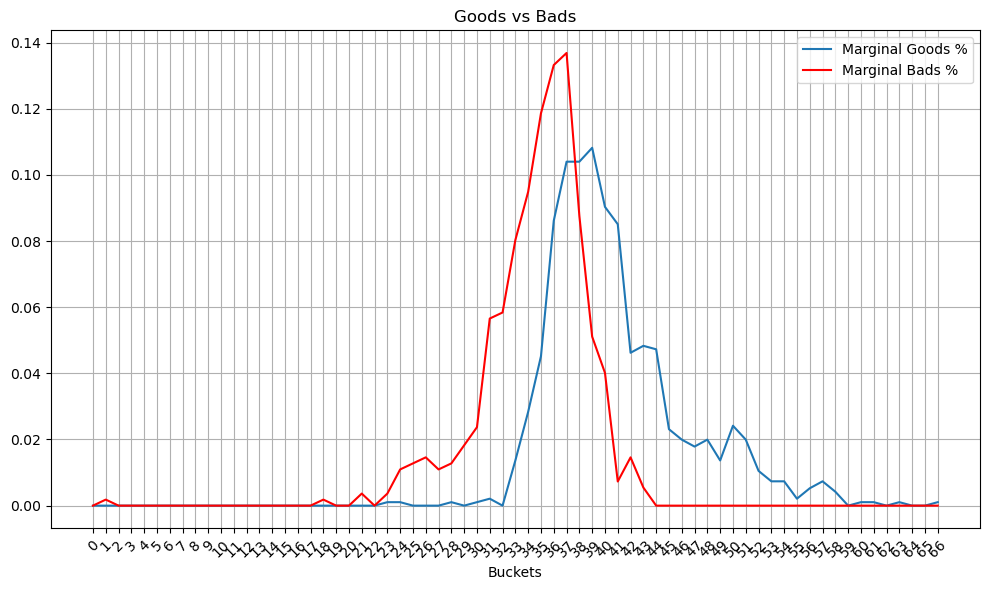

In [74]:
plt.figure(figsize=(10,6))
plt.plot(bucket_stats.index.astype(str),bucket_stats['marginal_%_Goods'],label= 'Marginal Goods %')
plt.plot(bucket_stats.index.astype(str),bucket_stats['marginal_%_Bads'],label= 'Marginal Bads %',color='red')
plt.title('Goods vs Bads')
plt.legend()
plt.grid(True)
plt.xlabel('Buckets')
plt.xticks(ticks=np.arange(0,len(bucket_stats.index),step=1),rotation=45)
plt.tight_layout()
plt.show()

In the above graph was can see that in:-

1) low scores Marginal bad rate is > Marginal Goods Rate.
2) High scores Marginal bad rate is < Marginal Goods Rate.
3) Therefore Scores us able to discriminate btwn goods and bads

# (ROC) Receiver Operating Characteristics

Text(0, 0.5, 'Cum % Bads')

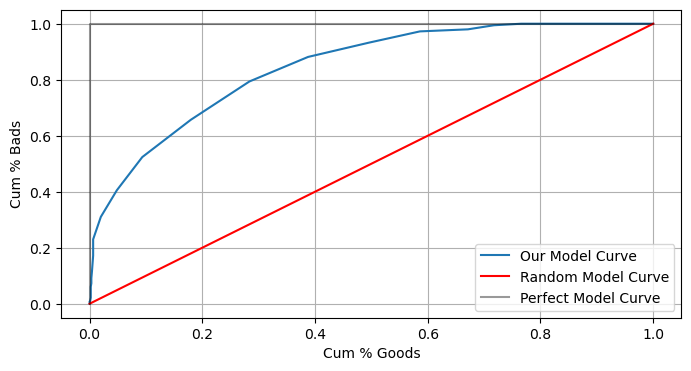

In [81]:
plt.figure(figsize=(8,4))
plt.plot(bucket_stats['cum_%_goods'],bucket_stats['cum_%_bads'],label='Our Model Curve')  # Curve for our Model
plt.plot([0,1],[0,1], color='red',label='Random Model Curve') #For Random Model
plt.plot([0,0,1],[0,1,1],alpha=0.40,color='black',label='Perfect Model Curve')
plt.legend()
plt.grid(True)
plt.xlabel('Cum % Goods')
plt.ylabel('Cum % Bads')

# Area Under The Curve (ROC AUC)

In [84]:
from sklearn.metrics import auc

In [86]:
x = bucket_stats['cum_%_goods']
y = bucket_stats['cum_%_bads']

In [88]:
roc_auc = auc(x,y)
roc_auc

0.8439953536158988

# Gini Coeff

In [91]:
gini = (2*roc_auc)-1
gini

0.6879907072317977

# KS PLOT

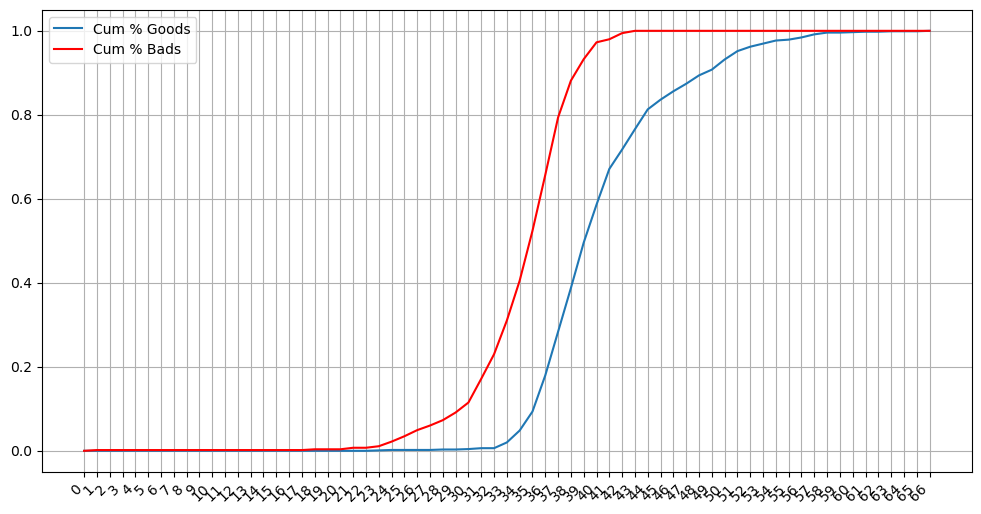

In [106]:
plt.figure(figsize=(12,6))
plt.plot(bucket_stats.index.astype(str),bucket_stats['cum_%_goods'],label='Cum % Goods')
plt.plot(bucket_stats.index.astype(str),bucket_stats['cum_%_bads'],label='Cum % Bads',color='red')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45,ha='right')
plt.show()

# KS Score/Statistic

In [109]:
ks_score = max(bucket_stats['cum_%_bads'] - bucket_stats['cum_%_goods'])
ks_score

0.5101821750598049

# KS Difference Curve

In [114]:
ks_df= bucket_stats.copy()

In [116]:
ks_df['cum_diff']= ks_df['cum_%_bads'] - ks_df['cum_%_goods']
ks_df

,Bucket,default,non_default,cum_goods,cum_bads,cum_%_goods,cum_%_bads,cum_%_total,marginal_%_Goods,marginal_%_Bads,cum_diff
0,"(0, 60]",0,0,0,0,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
1,"(60, 72]",1,0,0,1,0.000000,0.001825,0.000667,0.00000,0.001825,0.001825
2,"(72, 84]",0,0,0,1,0.000000,0.001825,0.000667,0.00000,0.000000,0.001825
3,"(84, 96]",0,0,0,1,0.000000,0.001825,0.000667,0.00000,0.000000,0.001825
4,"(96, 108]",0,0,0,1,0.000000,0.001825,0.000667,0.00000,0.000000,0.001825
...,...,...,...,...,...,...,...,...,...,...,...
62,"(792, 804]",0,0,950,548,0.997899,1.000000,0.998667,0.00000,0.000000,0.002101
63,"(804, 816]",0,1,951,548,0.998950,1.000000,0.999333,0.00105,0.000000,0.001050
64,"(816, 828]",0,0,951,548,0.998950,1.000000,0.999333,0.00000,0.000000,0.001050
65,"(828, 840]",0,0,951,548,0.998950,1.000000,0.999333,0.00000,0.000000,0.001050


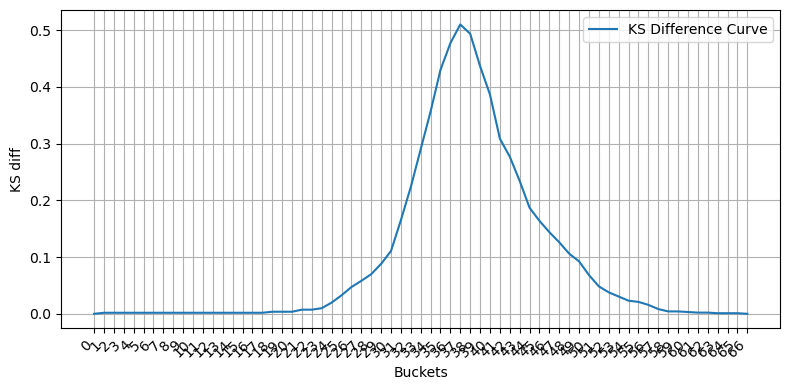

In [118]:
plt.figure(figsize=(8,4))
plt.plot(ks_df['cum_diff'],label= "KS Difference Curve")
plt.xlabel('Buckets')
plt.ylabel('KS diff')
plt.grid(True)
plt.legend()
plt.xticks(ticks=np.arange(0,len(bucket_stats.index),step=1),rotation=45,ha='right')
plt.tight_layout()
plt.show()

# Cumulative Accuracy Profile

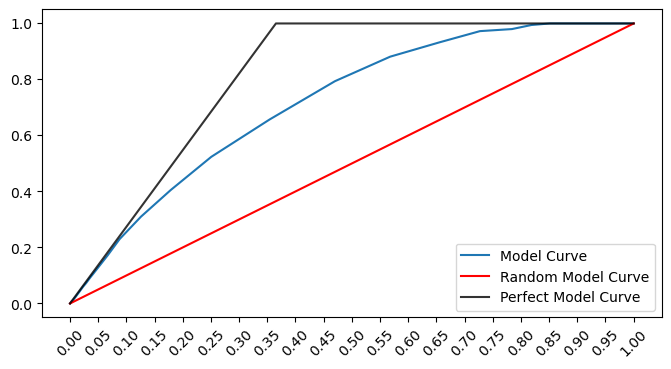

In [121]:
plt.figure(figsize=(8,4))
plt.plot(bucket_stats['cum_%_total'],bucket_stats['cum_%_bads'],label='Model Curve')
plt.plot([0,1],[0,1],color='red',label='Random Model Curve')
plt.plot([0,0.3653,1],[0,1,1],color='black',alpha=0.8,label='Perfect Model Curve')
plt.legend()
plt.xticks(ticks=np.arange(0,1.05,step=0.05),rotation=45)
plt.show()

# CAP AUC

In [124]:
#OUR MODEL AUC
X= bucket_stats['cum_%_total']
Y= bucket_stats['cum_%_bads']

CAP_AUC= auc(X,Y)
CAP_AUC

0.7183223844282238

In [126]:
accuracy_ratio = (CAP_AUC - 0.50) / (0.82 - 0.50)
accuracy_ratio

0.6822574513381996

# Pietra Index

In [140]:
pietra_index=(ks_score*np.sqrt(2)/4)
pietra_index

0.18037663781264518

# Confusion Matrix

In [143]:
df

,branch,ncust,customer,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,Y,pd_pred,Default_Pred,Grade,Score,Bucket
0,3,3017,10012,28,2,7,2,44,17.7,2.99,4.80,0,0.517544,0.626573,1,12,472.189844,"(468, 480]"
1,3,3017,10017,64,5,34,17,116,14.7,5.05,12.00,0,-6.042531,0.002370,0,2,661.473571,"(660, 672]"
2,3,3017,10030,40,1,20,12,61,4.8,1.04,1.89,0,-4.971149,0.006887,0,4,630.560048,"(624, 636]"
3,3,3017,10039,30,1,11,3,27,34.5,1.75,7.56,0,0.737179,0.676379,1,12,465.852521,"(456, 468]"
4,3,3017,10069,25,1,2,2,30,22.4,0.76,5.96,1,1.182130,0.765330,1,12,453.013952,"(444, 456]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,91,3779,453471,34,3,8,4,83,11.0,1.85,7.28,0,-1.144578,0.241481,0,10,520.148531,"(516, 528]"
1496,91,3779,453578,37,2,10,8,43,3.6,0.81,0.74,0,-2.985767,0.048073,0,8,573.274035,"(564, 576]"
1497,91,3779,453686,25,5,0,3,16,3.2,0.29,0.22,0,-0.746154,0.321660,0,11,508.652451,"(504, 516]"
1498,91,3779,453698,34,1,10,8,41,14.5,1.19,4.75,0,-1.492925,0.183483,0,10,530.199710,"(528, 540]"


<Axes: xlabel='Predicted', ylabel='Actual'>

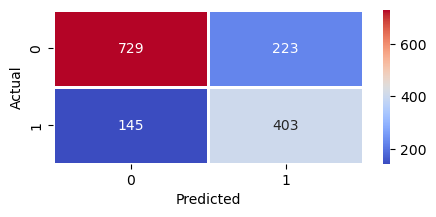

In [147]:
conf_matrix = pd.crosstab(df['default'],df['Default_Pred'],rownames=['Actual'],colnames=['Predicted'])
plt.figure(figsize=(5,2))
sns.heatmap(conf_matrix,annot= True,fmt='g',cmap='coolwarm',linewidth=1)

<Axes: xlabel='Predicted', ylabel='Actual'>

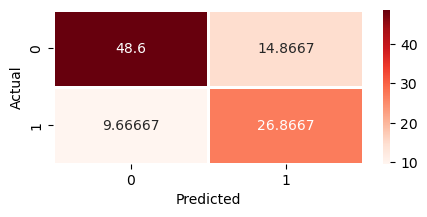

In [153]:
conf_matrix_norm = (conf_matrix/df.shape[0])*100
plt.figure(figsize=(5,2))
sns.heatmap(conf_matrix_norm,annot= True,fmt='g',cmap='Reds',linewidth=1)

# Precision and Recall

In [158]:
precision = conf_matrix_norm.iloc[1,1]/(conf_matrix_norm.iloc[1,1] + conf_matrix_norm.iloc[0,1])
precision

0.6437699680511182

In [160]:
recall = conf_matrix_norm.iloc[1,1]/(conf_matrix_norm.iloc[1,1] + conf_matrix_norm.iloc[1,0])
recall

0.7354014598540146

# Confusion Matrix Using Rating Grades

1) Cut off here is taken in terms of Grades. E.g :- For Grade 13
2) TP = count no of borrowers grade >= 13 , actual default status = 1
3)  FP = count no of borrowers grade >= 13 , actual default status = 0
4) TN = count no of borrowers grade < 13 , actual default status = 0
5) FN = count no of borrowers grade < 13 , actual default status = 1

In [173]:
grade_seg_df = pd.DataFrame({'Grade': range(1,14)})
grade_seg_df['TP']=0
grade_seg_df['FP']=0
grade_seg_df['TN']=0
grade_seg_df['FN']=0

In [175]:
grade_seg_df

,Grade,TP,FP,TN,FN
0,1,0,0,0,0
1,2,0,0,0,0
2,3,0,0,0,0
3,4,0,0,0,0
4,5,0,0,0,0
5,6,0,0,0,0
6,7,0,0,0,0
7,8,0,0,0,0
8,9,0,0,0,0
9,10,0,0,0,0


In [177]:
for idx,grade in enumerate(grade_seg_df['Grade']):
    TP_count = df[(df['Grade'] >= grade) & (df['default']==1)].shape[0]
    FP_count = df[(df['Grade'] >= grade) & (df['default']==0)].shape[0]
    TN_count = df[(df['Grade'] < grade) & (df['default']==0)].shape[0]
    FN_count = df[(df['Grade'] < grade) & (df['default']==1)].shape[0]
# To assign values we can use .iloc or .loc but Since we want to assign values to a single cell, we can use .at

    grade_seg_df.at[idx,'TP']=TP_count
    grade_seg_df.at[idx,'FP']=FP_count
    grade_seg_df.at[idx,'TN']=TN_count
    grade_seg_df.at[idx,'FN']=FN_count

In [179]:
grade_seg_df

,Grade,TP,FP,TN,FN
0,1,548,952,0,0
1,2,548,906,46,0
2,3,548,881,71,0
3,4,548,857,95,0
4,5,548,830,122,0
5,6,548,809,143,0
6,7,548,780,172,0
7,8,547,723,229,1
8,9,539,656,296,9
9,10,530,549,403,18


In [181]:
# Find TPR, FPR, TNR, FNR for each grade:-
grade_seg_df['TPR']= grade_seg_df['TP']/(grade_seg_df['TP'] + grade_seg_df['FN'])*100
grade_seg_df['FPR']= grade_seg_df['FP']/(grade_seg_df['FP'] + grade_seg_df['TN'])*100
grade_seg_df['TNR']= grade_seg_df['TN']/(grade_seg_df['TN'] + grade_seg_df['FP'])*100
grade_seg_df['FNR']= grade_seg_df['FN']/(grade_seg_df['FN'] + grade_seg_df['TP'])*100

In [183]:
grade_seg_df

,Grade,TP,FP,TN,FN,TPR,FPR,TNR,FNR
0,1,548,952,0,0,100.000000,100.000000,0.000000,0.000000
1,2,548,906,46,0,100.000000,95.168067,4.831933,0.000000
2,3,548,881,71,0,100.000000,92.542017,7.457983,0.000000
3,4,548,857,95,0,100.000000,90.021008,9.978992,0.000000
4,5,548,830,122,0,100.000000,87.184874,12.815126,0.000000
5,6,548,809,143,0,100.000000,84.978992,15.021008,0.000000
6,7,548,780,172,0,100.000000,81.932773,18.067227,0.000000
7,8,547,723,229,1,99.817518,75.945378,24.054622,0.182482
8,9,539,656,296,9,98.357664,68.907563,31.092437,1.642336
9,10,530,549,403,18,96.715328,57.668067,42.331933,3.284672


# Direct Method For Confusion Matrix

In [191]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

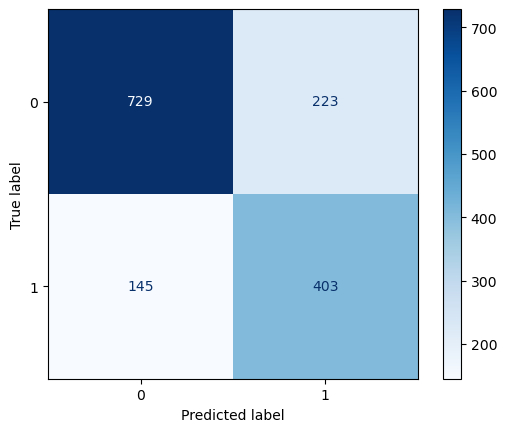

In [193]:
cm= confusion_matrix(df['default'],df['Default_Pred'])
disp= ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues')

In [195]:
def confusion_matrix_with_threshold(data,default_col,pd_col,threshold):
    predictions = (data[pd_col] >= threshold).astype(int)
    cm = confusion_matrix(data[default_col],predictions)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap='Reds',)
    return predictions

0       1
1       0
2       0
3       1
4       1
       ..
1495    0
1496    0
1497    0
1498    0
1499    0
Name: pd_pred, Length: 1500, dtype: int32

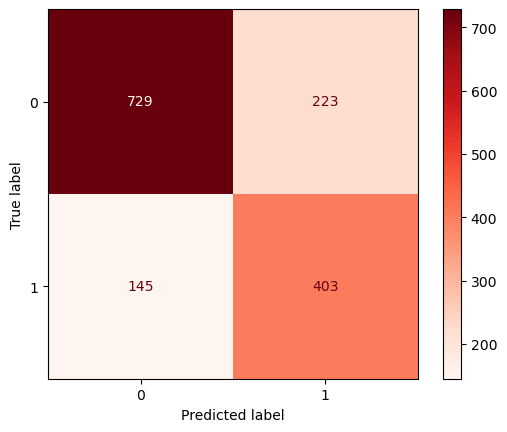

In [197]:
confusion_matrix_with_threshold(df,'default','pd_pred',0.4)

 # Classification Report

In [204]:
from sklearn.metrics import classification_report

In [206]:
report= classification_report(df['default'],df['Default_Pred'])
print(report)
# Precision, Recall, F1-Score for 1(default) match with our numbers.

              precision    recall  f1-score   support

           0       0.83      0.77      0.80       952
           1       0.64      0.74      0.69       548

    accuracy                           0.75      1500
   macro avg       0.74      0.75      0.74      1500
weighted avg       0.76      0.75      0.76      1500



# Weight Of Evidence

In [216]:
df3=df.groupby('Grade').agg(
    goods = ('default',lambda x:(x==0).sum()),
    bads = ('default',lambda x:(x==1).sum())
)

In [218]:
df3=df3.reset_index()

In [220]:
df3['total']= df3['goods'] + df3['bads']
df3

,Grade,goods,bads,total
0,1,46,0,46
1,2,25,0,25
2,3,24,0,24
3,4,27,0,27
4,5,21,0,21
5,6,29,0,29
6,7,57,1,58
7,8,67,8,75
8,9,107,9,116
9,10,162,45,207


In [222]:
total_bads = (df['default']==1).sum()
total_bads

548

In [224]:
total_goods = (df['default']==0).sum()
total_goods

952

In [226]:
df3['Marg_%_Goods'] = df3['goods']/total_goods
df3['Marg_%_Bads'] = df3['bads']/total_bads

In [228]:
df3

,Grade,goods,bads,total,Marg_%_Goods,Marg_%_Bads
0,1,46,0,46,0.048319,0.000000
1,2,25,0,25,0.026261,0.000000
2,3,24,0,24,0.025210,0.000000
3,4,27,0,27,0.028361,0.000000
4,5,21,0,21,0.022059,0.000000
5,6,29,0,29,0.030462,0.000000
6,7,57,1,58,0.059874,0.001825
7,8,67,8,75,0.070378,0.014599
8,9,107,9,116,0.112395,0.016423
9,10,162,45,207,0.170168,0.082117


In [235]:
df3['WOE']= np.log(df3['Marg_%_Bads']/df3['Marg_%_Goods'])
df3

,Grade,goods,bads,total,Marg_%_Goods,Marg_%_Bads,WOE
0,1,46,0,46,0.048319,0.000000,-inf
1,2,25,0,25,0.026261,0.000000,-inf
2,3,24,0,24,0.025210,0.000000,-inf
3,4,27,0,27,0.028361,0.000000,-inf
4,5,21,0,21,0.022059,0.000000,-inf
5,6,29,0,29,0.030462,0.000000,-inf
6,7,57,1,58,0.059874,0.001825,-3.490762
7,8,67,8,75,0.070378,0.014599,-1.572961
8,9,107,9,116,0.112395,0.016423,-1.923315
9,10,162,45,207,0.170168,0.082117,-0.728644


In [237]:
df3['IV']=(df3['Marg_%_Bads']- df3['Marg_%_Goods']) * np.log(df3['Marg_%_Bads']/df3['Marg_%_Goods'])

In [239]:
df3.replace([np.inf, -np.inf], 0, inplace=True)

In [241]:
df3

,Grade,goods,bads,total,Marg_%_Goods,Marg_%_Bads,WOE,IV
0,1,46,0,46,0.048319,0.000000,0.000000,0.000000
1,2,25,0,25,0.026261,0.000000,0.000000,0.000000
2,3,24,0,24,0.025210,0.000000,0.000000,0.000000
3,4,27,0,27,0.028361,0.000000,0.000000,0.000000
4,5,21,0,21,0.022059,0.000000,0.000000,0.000000
5,6,29,0,29,0.030462,0.000000,0.000000,0.000000
6,7,57,1,58,0.059874,0.001825,-3.490762,0.202636
7,8,67,8,75,0.070378,0.014599,-1.572961,0.087739
8,9,107,9,116,0.112395,0.016423,-1.923315,0.184584
9,10,162,45,207,0.170168,0.082117,-0.728644,0.064158


# Entropy , KL Divergence , CIER

In [244]:
default_rate= df['default'].mean()
p = default_rate
p

0.36533333333333334

In [253]:
uncond_entropy = -p*np.log2(p) - (1-p)*np.log2(1-p)
uncond_entropy

0.9470213906288893

In [255]:
df3['%Bad']= df3['bads']/df3['total']
df3

,Grade,goods,bads,total,Marg_%_Goods,Marg_%_Bads,WOE,IV,%Bad
0,1,46,0,46,0.048319,0.000000,0.000000,0.000000,0.000000
1,2,25,0,25,0.026261,0.000000,0.000000,0.000000,0.000000
2,3,24,0,24,0.025210,0.000000,0.000000,0.000000,0.000000
3,4,27,0,27,0.028361,0.000000,0.000000,0.000000,0.000000
4,5,21,0,21,0.022059,0.000000,0.000000,0.000000,0.000000
5,6,29,0,29,0.030462,0.000000,0.000000,0.000000,0.000000
6,7,57,1,58,0.059874,0.001825,-3.490762,0.202636,0.017241
7,8,67,8,75,0.070378,0.014599,-1.572961,0.087739,0.106667
8,9,107,9,116,0.112395,0.016423,-1.923315,0.184584,0.077586
9,10,162,45,207,0.170168,0.082117,-0.728644,0.064158,0.217391


In [257]:
df3['Entropy'] = -df3['%Bad']*np.log2(df3['%Bad']) - (1-df3['%Bad'])*np.log2(1-df3['%Bad'])

In [259]:
df3=df3.fillna(0)

In [261]:
df3

,Grade,goods,bads,total,Marg_%_Goods,Marg_%_Bads,WOE,IV,%Bad,Entropy
0,1,46,0,46,0.048319,0.000000,0.000000,0.000000,0.000000,0.000000
1,2,25,0,25,0.026261,0.000000,0.000000,0.000000,0.000000,0.000000
2,3,24,0,24,0.025210,0.000000,0.000000,0.000000,0.000000,0.000000
3,4,27,0,27,0.028361,0.000000,0.000000,0.000000,0.000000,0.000000
4,5,21,0,21,0.022059,0.000000,0.000000,0.000000,0.000000,0.000000
5,6,29,0,29,0.030462,0.000000,0.000000,0.000000,0.000000,0.000000
6,7,57,1,58,0.059874,0.001825,-3.490762,0.202636,0.017241,0.125658
7,8,67,8,75,0.070378,0.014599,-1.572961,0.087739,0.106667,0.489779
8,9,107,9,116,0.112395,0.016423,-1.923315,0.184584,0.077586,0.393616
9,10,162,45,207,0.170168,0.082117,-0.728644,0.064158,0.217391,0.755375


In [263]:
cond_entropy = (df3['Entropy'] * df3['total']).sum() / df3['total'].sum()
cond_entropy

0.6641259689216583

In [265]:
KL_divergence = uncond_entropy - cond_entropy
KL_divergence

0.28289542170723103

In [267]:
CIER = KL_divergence/uncond_entropy
CIER

0.2987212585761853